# Baseline IDS Analysis — CICIDS2023


This notebook covers:
- Dataset exploration and class distribution
- Data preprocessing (encoding, NaN handling, infinite value removal)
- Binary classification: Normal vs Attack
- Multi-class classification across all attack types
- Feature importance analysis
- Baseline results for comparison against adaptive model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 2. Load Dataset

In [2]:
df = pd.read_csv('Merged01.csv', nrows=50000)

print('Shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
print('\nColumn names:')
print(list(df.columns))

Shape: (50000, 40)
Missing values: 0

Column names:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']


## 3. Exploratory Data Analysis

Class distribution:
Label
DDOS-ICMP_FLOOD            7800
DDOS-UDP_FLOOD             5666
DDOS-TCP_FLOOD             4889
DDOS-SYN_FLOOD             4253
DDOS-RSTFINFLOOD           4250
DDOS-PSHACK_FLOOD          4238
DDOS-SYNONYMOUSIP_FLOOD    3720
DOS-UDP_FLOOD              3555
DOS-TCP_FLOOD              2823
DOS-SYN_FLOOD              2253
BENIGN                     1171
MIRAI-GREETH_FLOOD         1077
MIRAI-UDPPLAIN              975
MIRAI-GREIP_FLOOD           776
DDOS-ICMP_FRAGMENTATION     510
VULNERABILITYSCAN           406
MITM-ARPSPOOFING            342
DDOS-ACK_FRAGMENTATION      312
DDOS-UDP_FRAGMENTATION      289
DNS_SPOOFING                177
RECON-HOSTDISCOVERY         163
RECON-OSSCAN                101
RECON-PORTSCAN               97
DOS-HTTP_FLOOD               70
DDOS-SLOWLORIS               22
DDOS-HTTP_FLOOD              22
DICTIONARYBRUTEFORCE         13
COMMANDINJECTION              6
RECON-PINGSWEEP               6
BROWSERHIJACKING              5
XSS           

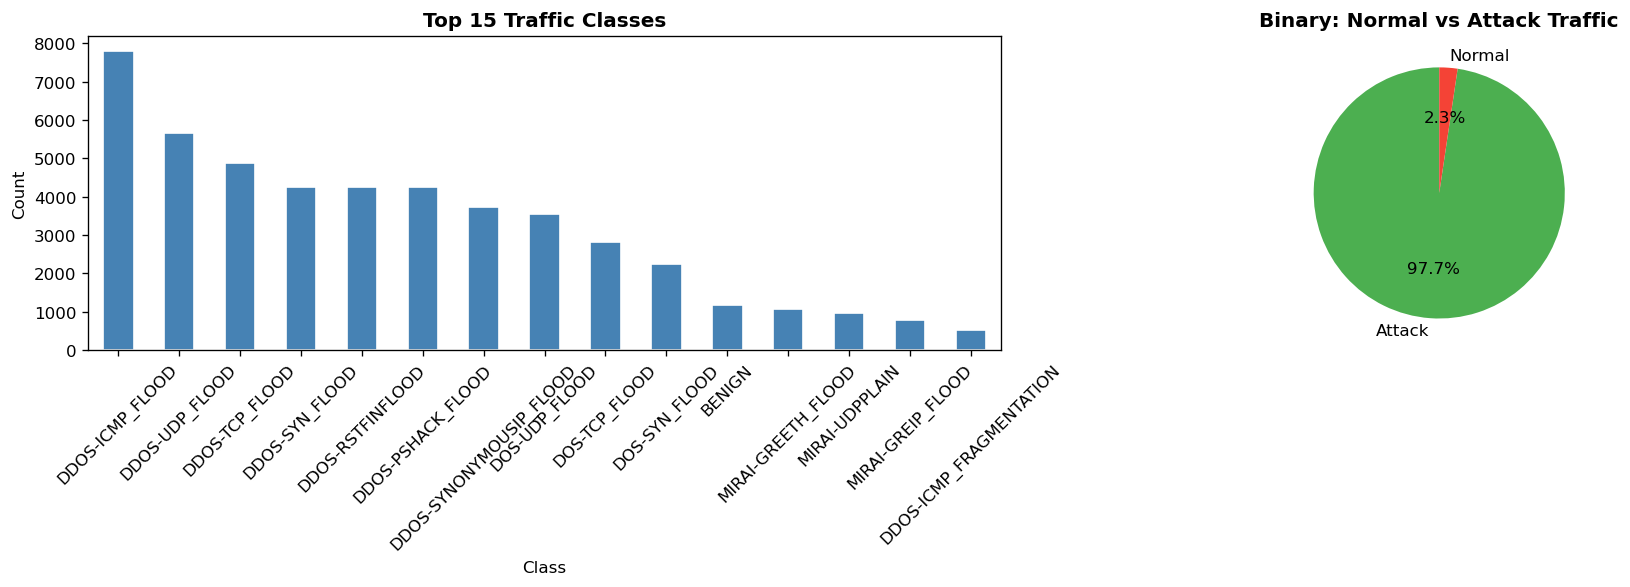

In [3]:
label_counts = df['Label'].value_counts()
print('Class distribution:')
print(label_counts.to_string())
print(f'\nTotal classes: {len(label_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_counts.head(15).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Traffic Classes', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Binary_Label'] = df['Label'].apply(lambda x: 'Normal' if x == 'BENIGN' else 'Attack')
binary_counts = df['Binary_Label'].value_counts()
axes[1].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Binary: Normal vs Attack Traffic', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [4]:
df_clean = df.copy()

# Remove NaN and infinite values
df_clean = df_clean.dropna()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna()
print(f'Clean dataset shape: {df_clean.shape}')

# Multi-class label encoding
encoder = LabelEncoder()
df_clean['Label_encoded'] = encoder.fit_transform(df_clean['Label'])
print(f'Classes ({len(encoder.classes_)}): {list(encoder.classes_)}')

# Binary label encoding
df_clean['Binary_encoded'] = (df_clean['Binary_Label'] == 'Attack').astype(int)

# Feature matrix — all columns except label columns
feature_cols = [c for c in df_clean.columns
                if c not in ['Label', 'Binary_Label', 'Label_encoded', 'Binary_encoded']]
X = df_clean[feature_cols]
print(f'Features: {len(feature_cols)}')

Clean dataset shape: (50000, 41)
Classes (33): ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'VULNERABILITYSCAN', 'XSS']
Features: 39


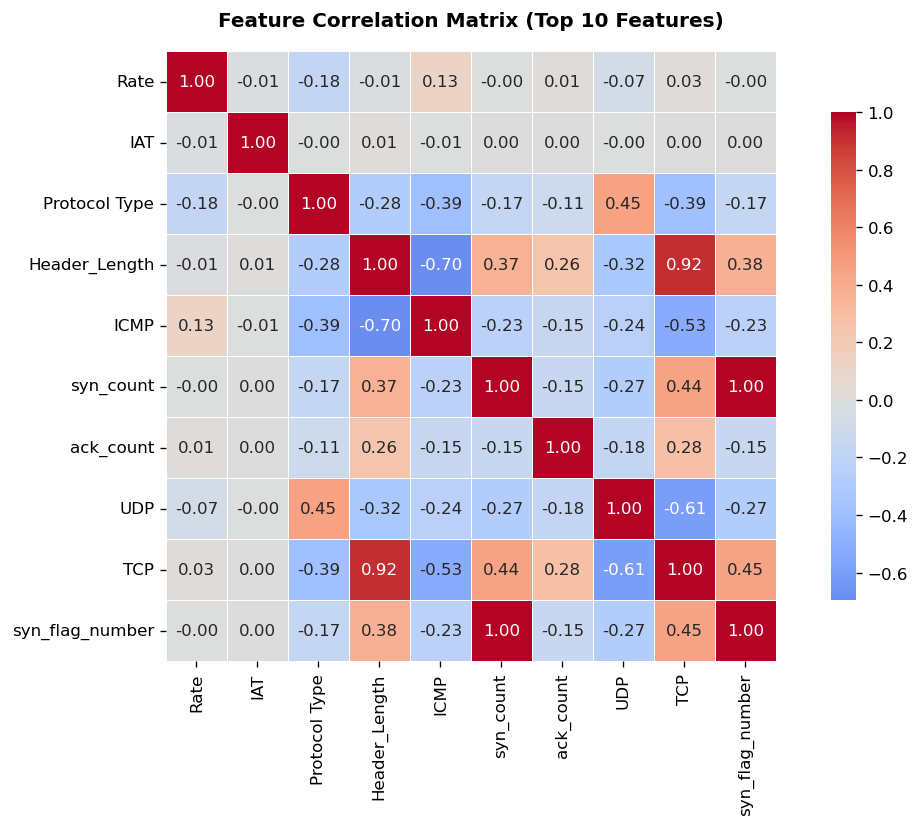

In [5]:
# Feature correlation heatmap
top_features = ['Rate', 'IAT', 'Protocol Type', 'Header_Length', 'ICMP',
                'syn_count', 'ack_count', 'UDP', 'TCP', 'syn_flag_number']

plt.figure(figsize=(10, 7))
corr = df_clean[top_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Top 10 Features)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../results/feature_correlation.png', bbox_inches='tight')
plt.show()

## 5. Binary Classification — Normal vs Attack

In [6]:
y_binary = df_clean['Binary_encoded']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f'Train: {len(X_train_b)}  |  Test: {len(X_test_b)}')

rf_binary = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_binary.fit(X_train_b, y_train_b)

y_pred_b = rf_binary.predict(X_test_b)
acc_b = accuracy_score(y_test_b, y_pred_b)
f1_b  = f1_score(y_test_b, y_pred_b, average='weighted')

print(f'\nBinary Classification Results')
print(f'Accuracy : {acc_b:.4f} ({acc_b*100:.2f}%)')
print(f'F1 Score : {f1_b:.4f}')
print()
print(classification_report(y_test_b, y_pred_b,
                             target_names=['Normal', 'Attack'], zero_division=0))

Train: 40000  |  Test: 10000

Binary Classification Results
Accuracy : 0.9917 (99.17%)
F1 Score : 0.9915

              precision    recall  f1-score   support

      Normal       0.86      0.77      0.81       234
      Attack       0.99      1.00      1.00      9766

    accuracy                           0.99     10000
   macro avg       0.93      0.89      0.90     10000
weighted avg       0.99      0.99      0.99     10000



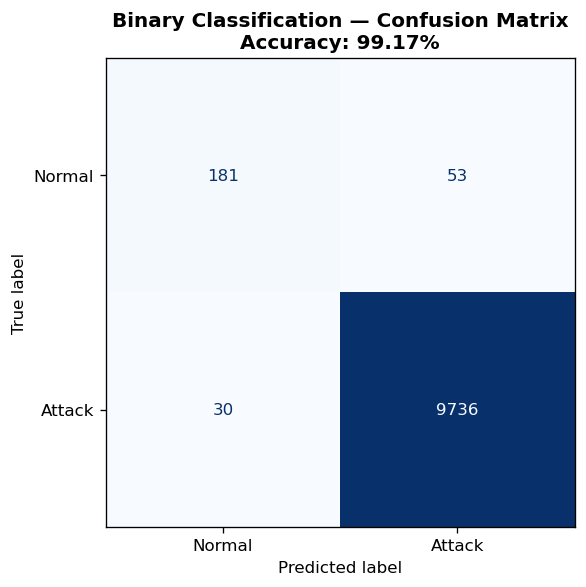

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Binary Classification — Confusion Matrix\nAccuracy: {acc_b*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 6. Multi-Class Classification — All Attack Types

In [8]:
y_multi = df_clean['Label_encoded']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_multi.fit(X_train_m, y_train_m)

y_pred_m = rf_multi.predict(X_test_m)
acc_m = accuracy_score(y_test_m, y_pred_m)
f1_m  = f1_score(y_test_m, y_pred_m, average='weighted', zero_division=0)

print(f'Multi-Class Results')
print(f'Accuracy : {acc_m:.4f} ({acc_m*100:.2f}%)')
print(f'F1 Score : {f1_m:.4f}')
print()
print(classification_report(y_test_m, y_pred_m,
                             target_names=encoder.classes_, zero_division=0))

Multi-Class Results
Accuracy : 0.7545 (75.45%)
F1 Score : 0.7521

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.00      0.00      0.00         1
                 BENIGN       0.75      0.88      0.81       234
       BROWSERHIJACKING       0.00      0.00      0.00         1
       COMMANDINJECTION       0.00      0.00      0.00         1
 DDOS-ACK_FRAGMENTATION       0.91      0.97      0.94        62
        DDOS-HTTP_FLOOD       0.00      0.00      0.00         4
        DDOS-ICMP_FLOOD       1.00      1.00      1.00      1560
DDOS-ICMP_FRAGMENTATION       0.99      0.98      0.99       102
      DDOS-PSHACK_FLOOD       1.00      1.00      1.00       848
       DDOS-RSTFINFLOOD       1.00      1.00      1.00       850
         DDOS-SLOWLORIS       0.40      0.50      0.44         4
DDOS-SYNONYMOUSIP_FLOOD       0.47      0.47      0.47       744
         DDOS-SYN_FLOOD       0.47      0.48      0.47       851
         DDOS-TCP_FLOOD

## 7. Feature Importance

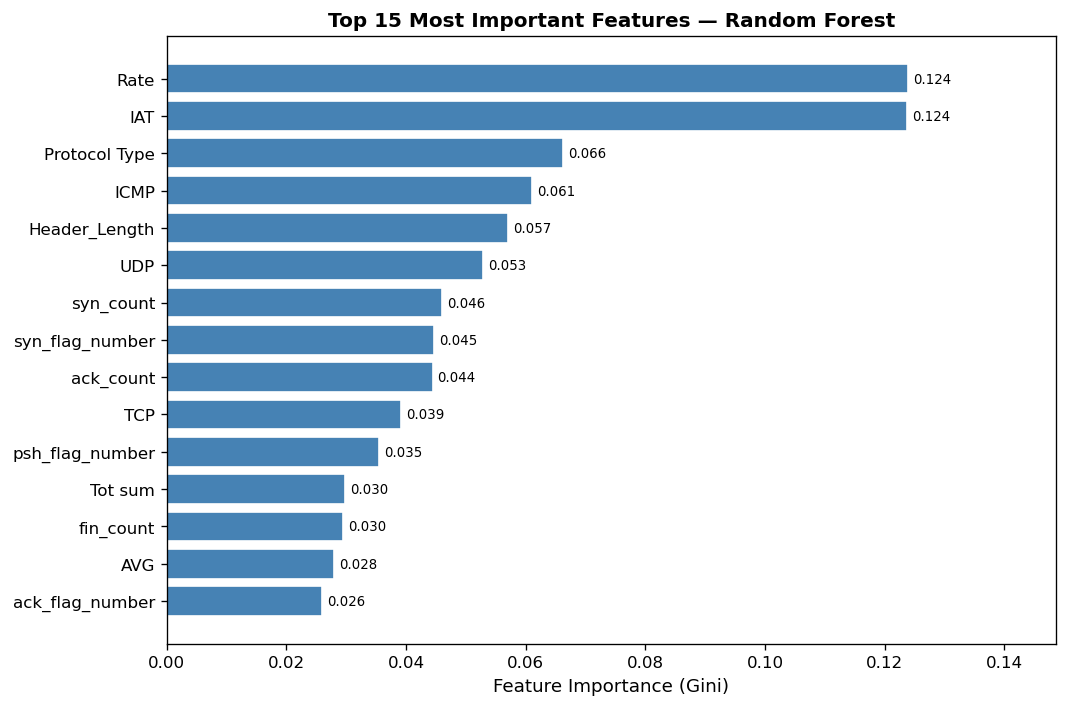

Top 5 features:
      Feature  Importance
         Rate    0.123850
          IAT    0.123792
Protocol Type    0.066233
         ICMP    0.061121
Header_Length    0.057076


In [9]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_multi.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Most Important Features — Random Forest', fontweight='bold', fontsize=12)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance_df.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

## 8. Baseline Results Summary

In [10]:
print('=' * 55)
print('         BASELINE MODEL RESULTS SUMMARY')
print('=' * 55)
print(f'Dataset          : CICIDS2023 — Merged01.csv')
print(f'Samples          : {len(df_clean):,}')
print(f'Features         : {len(feature_cols)}')
print(f'Classes          : {len(encoder.classes_)}')
print('-' * 55)
print(f'Binary  Accuracy : {acc_b*100:.2f}%   |  F1: {f1_b:.4f}')
print(f'Multi   Accuracy : {acc_m*100:.2f}%   |  F1: {f1_m:.4f}')
print('=' * 55)
print('Note: Static model — trained once, no drift adaptation.')
print('Adaptive ADWIN model: see adaptive_ids_adwin.ipynb')

         BASELINE MODEL RESULTS SUMMARY
Dataset          : CICIDS2023 — Merged01.csv
Samples          : 50,000
Features         : 39
Classes          : 33
-------------------------------------------------------
Binary  Accuracy : 99.17%   |  F1: 0.9915
Multi   Accuracy : 75.45%   |  F1: 0.7521
Note: Static model — trained once, no drift adaptation.
Adaptive ADWIN model: see adaptive_ids_adwin.ipynb
